# IPL: reproducible performance analysis
**Harshit Kotnala · Sports exploratory data analysis**

Revised analysis of the original 2008–2019 CSV files. This notebook keeps the original project’s IPL focus while correcting outcome classification, date parsing, and player denominators. Results describe the supplied data, not a current or independently audited score database.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd() if (Path.cwd() / 'analytics.py').exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from analytics import *
sns.set_theme(style='whitegrid', palette='colorblind')
matches = load_ipl()
deliveries = pd.read_csv(ROOT / "deliveries.csv")
print(f"{len(matches):,} matches; {len(deliveries):,} delivery records")
matches.head()

756 matches; 179,078 delivery records


,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3,outcome
0,60,2008,Bangalore,2008-04-18,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Kolkata Knight Riders,140,0,BB McCullum,M Chinnaswamy Stadium,Asad Rauf,RE Koertzen,NaN,Bat first
1,61,2008,Chandigarh,2008-04-19,Chennai Super Kings,Kings XI Punjab,Chennai Super Kings,bat,normal,0,Chennai Super Kings,33,0,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",MR Benson,SL Shastri,NaN,Bat first
2,62,2008,Delhi,2008-04-19,Rajasthan Royals,Delhi Capitals,Rajasthan Royals,bat,normal,0,Delhi Capitals,0,9,MF Maharoof,Feroz Shah Kotla,Aleem Dar,GA Pratapkumar,NaN,Chase
3,63,2008,Mumbai,2008-04-20,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,normal,0,Royal Challengers Bangalore,0,5,MV Boucher,Wankhede Stadium,SJ Davis,DJ Harper,NaN,Chase
4,64,2008,Kolkata,2008-04-20,Deccan Chargers,Kolkata Knight Riders,Deccan Chargers,bat,normal,0,Kolkata Knight Riders,0,5,DJ Hussey,Eden Gardens,BF Bowden,K Hariharan,NaN,Chase


## 1. Data quality before analysis
Missing winners are retained as no-results. Missing umpires or venues are not invented. Repeated delivery coordinates may represent wides/no-balls and are not automatically removed. The original files remain unchanged.

In [2]:
pd.DataFrame({'missing': matches.isna().sum(), 'missing_pct': matches.isna().mean() * 100}).sort_values('missing', ascending=False)

,missing,missing_pct
umpire3,637,84.259259
city,7,0.925926
winner,4,0.529101
player_of_match,4,0.529101
umpire2,2,0.264550
umpire1,2,0.264550
id,0,0.000000
venue,0,0.000000
win_by_wickets,0,0.000000
win_by_runs,0,0.000000


In [3]:
assert matches.id.is_unique
assert deliveries.match_id.isin(matches.id).all()
print('Exact duplicate delivery rows:', deliveries.duplicated().sum())
print('Seasons:', sorted(matches.season.unique()))
print('Unresolved matches:', matches.winner.isna().sum())

Exact duplicate delivery rows: 23
Seasons: [np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019)]
Unresolved matches: 4


## 2. Match volume and team performance
Win rate uses **decided matches**, including tiebreak-decided games, as the denominator. No-results are shown separately. Counts reflect opportunities as well as performance; they are not championship totals.

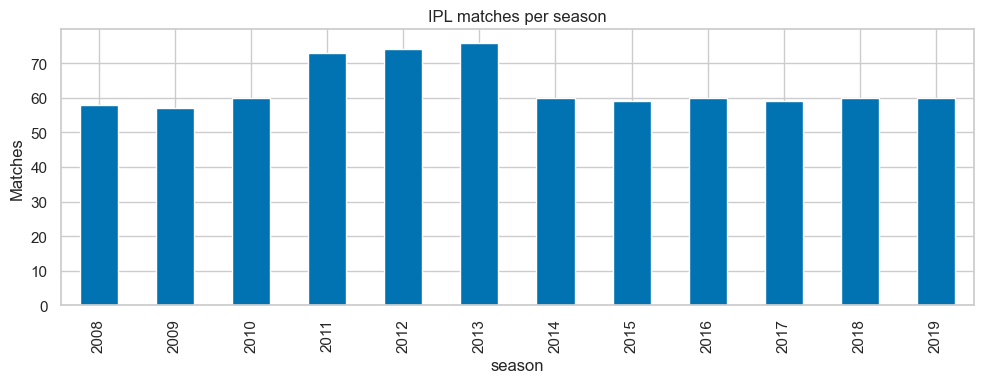

In [4]:
matches.groupby('season').size().plot.bar(figsize=(10, 4), title='IPL matches per season', ylabel='Matches')
plt.tight_layout()
plt.show()

,team,matches,wins,decided,no_result,losses,win_pct
0,Mumbai Indians,187,109,187,0,78,58.29
1,Chennai Super Kings,164,100,164,0,64,60.98
2,Kolkata Knight Riders,178,92,178,0,86,51.69
3,Royal Challengers Bangalore,180,84,177,3,93,47.46
4,Kings XI Punjab,176,82,176,0,94,46.59
5,Delhi Capitals,177,77,175,2,98,44.00
6,Rajasthan Royals,147,75,145,2,70,51.72
7,Sunrisers Hyderabad,108,58,108,0,50,53.70
8,Deccan Chargers,75,29,75,0,46,38.67
9,Rising Pune Supergiant,30,15,30,0,15,50.00


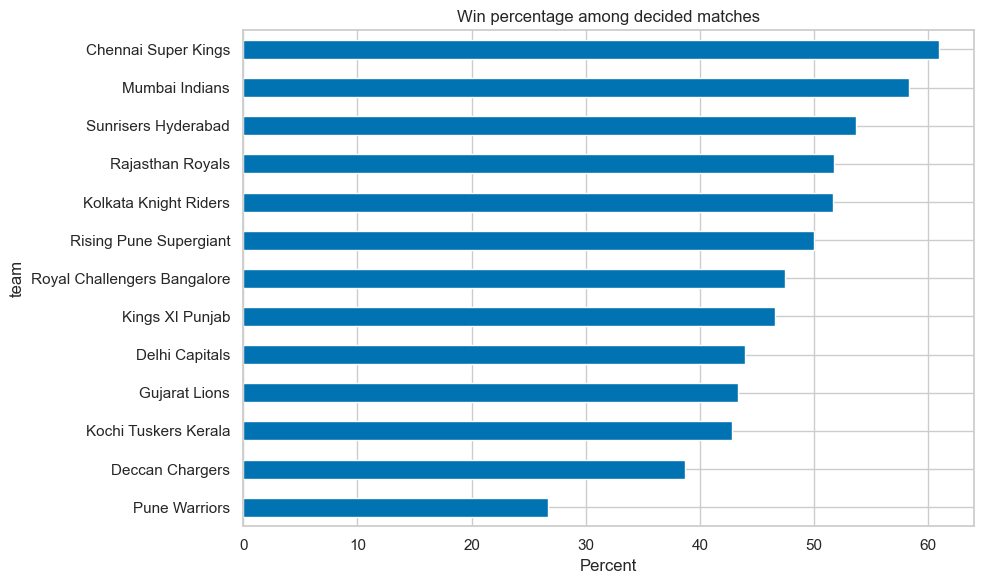

In [5]:
teams = ipl_team_summary(matches)
display(teams.round(2))
teams.sort_values('win_pct').plot.barh(x='team', y='win_pct', figsize=(10, 6), legend=False, title='Win percentage among decided matches', xlabel='Percent')
plt.tight_layout()
plt.show()

## 3. Outcomes and toss decisions
A zero run margin does not automatically mean a chasing win. Separate run-margin wins, wicket-margin wins, tiebreaks, and no-results. Toss association alone cannot establish a causal advantage; venue, team quality, weather, and era are confounders.

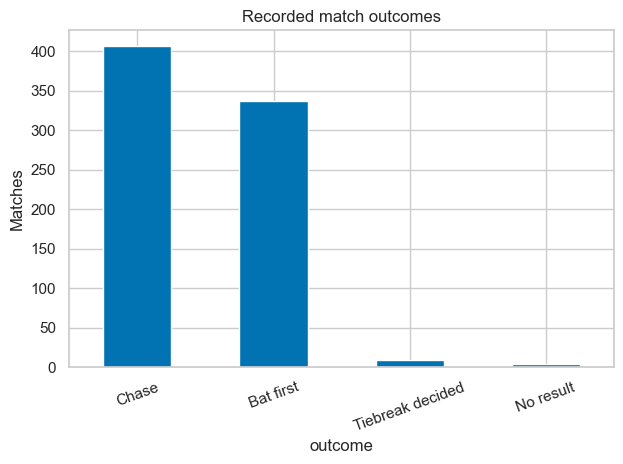

,matches,toss_winner_win_rate
toss_decision,,
bat,292,0.458904
field,460,0.563043


In [6]:
matches.outcome.value_counts().plot.bar(title='Recorded match outcomes', ylabel='Matches', rot=20)
plt.tight_layout()
plt.show()
decided = matches[matches.winner.notna()].copy()
decided['toss_winner_won'] = decided.toss_winner.eq(decided.winner)
display(decided.groupby('toss_decision').agg(matches=('id', 'size'), toss_winner_win_rate=('toss_winner_won', 'mean')))

## 4. Player production
Super-over deliveries are excluded from standard innings totals. Batting appearances count distinct matches where a player is observed as striker **or non-striker**, not dismissals or playing-XI selections. Runs describe source records; no unsupported official-record claim is made.

,batting_appearances,runs,fours,sixes
batsman,,,,
V Kohli,169,5429.0,481.0,191.0
SK Raina,189,5407.0,495.0,194.0
RG Sharma,183,4914.0,431.0,194.0
DA Warner,126,4741.0,459.0,181.0
S Dhawan,158,4632.0,526.0,96.0
CH Gayle,124,4535.0,373.0,326.0
MS Dhoni,170,4477.0,297.0,207.0
RV Uthappa,170,4446.0,436.0,156.0
AB de Villiers,142,4415.0,357.0,212.0


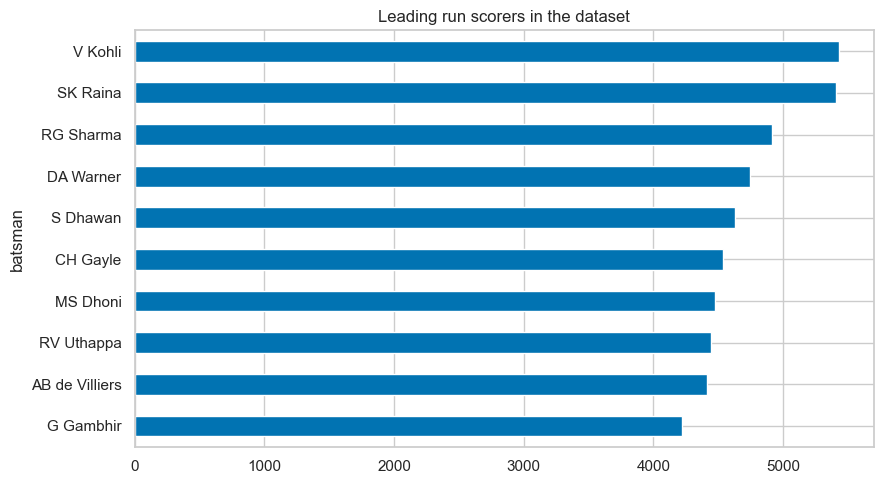

In [7]:
batting, bowling = ipl_players()
display(batting.head(15))
batting.head(10).sort_values('runs').plot.barh(y='runs', figsize=(9, 5), title='Leading run scorers in the dataset', legend=False)
plt.tight_layout()
plt.show()

## 5. Bowling
Only bowler-credited dismissal types count as wickets. Run-outs, retired hurt, and obstructing the field are excluded. Economy = 6 × runs conceded / legal balls; byes, leg-byes and penalties are removed from runs conceded. A bowler with no legal balls has undefined economy, not zero.

,wickets,legal_balls,runs_conceded,economy
bowler,,,,
SL Malinga,170,2827,3390,7.19
A Mishra,156,3102,3804,7.36
Harbhajan Singh,150,3374,3979,7.08
PP Chawla,149,3125,4086,7.85
DJ Bravo,147,2586,3662,8.50
B Kumar,133,2612,3185,7.32
R Ashwin,125,2925,3337,6.85
SP Narine,122,2557,2873,6.74
UT Yadav,119,2483,3535,8.54


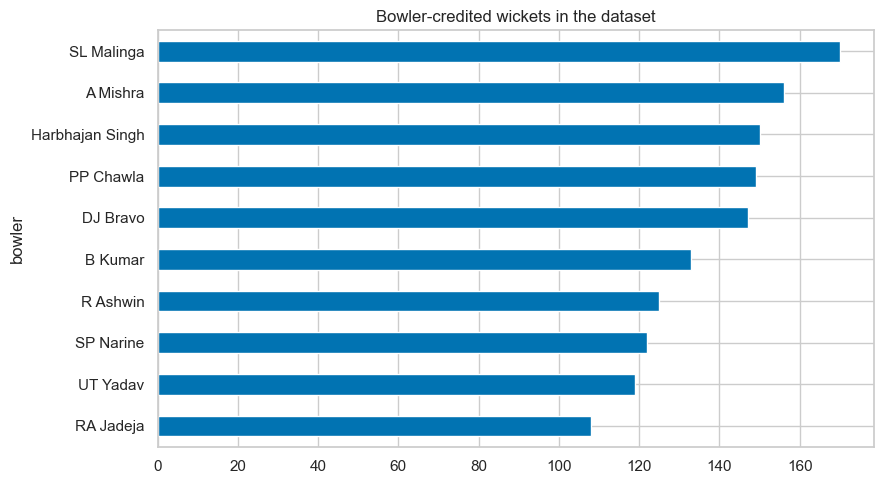

In [8]:
display(bowling.head(15).round(2))
bowling.head(10).sort_values('wickets').plot.barh(y='wickets', figsize=(9, 5), title='Bowler-credited wickets in the dataset', legend=False)
plt.tight_layout()
plt.show()

## 6. Findings generated from this run
No championship is inferred from row order. For verified championship editions across five sports, open `Global Sports EDA.ipynb`. The data supports descriptive analysis, not causal statements or forecasts.

In [9]:
counts = matches.groupby('season').size()
print(f'Most matches: {counts.idxmax()} ({counts.max()}).')
print(f'Most match wins: {teams.iloc[0].team} ({teams.iloc[0].wins}).')
print(f'Toss winner also won {decided.toss_winner_won.mean():.1%} of {len(decided)} decided matches.')
print(f'Leading run scorer in supplied data: {batting.index[0]} ({int(batting.iloc[0].runs):,}).')
print(f'Leading wicket taker in supplied data: {bowling.index[0]} ({int(bowling.iloc[0].wickets)}).')

Most matches: 2013 (76).
Most match wins: Mumbai Indians (109).
Toss winner also won 52.3% of 752 decided matches.
Leading run scorer in supplied data: V Kohli (5,429).
Leading wicket taker in supplied data: SL Malinga (170).
